# **Data Load and pre-process**

In [6]:
import os, random, time, csv
from pathlib import Path
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU not available (forced GPU-only mode)")
DEVICE = torch.device("cuda:0")

FELINE_IMG_PATH = "/kaggle/input/cat-reticulocyte/felineAlldata"
HUMAN_IMG_PATH  = "/kaggle/input/human-reticulocyte/SubsetAlldata"

META_EPOCHS, EPISODES_PER_EPOCH = 20, 30
LR = 1e-4
SAVE_ROOT = Path("outputs_fsl_eval"); SAVE_ROOT.mkdir(parents=True, exist_ok=True)

N_WAY_TRAIN_TEACHER = 3  # episodic 3-way meta-train on feline
N_WAY_STUDENT = 3        # student 3-way episodes (must include reticulocyte)
K_SHOT = 10
Q_QUERY = 15

EVAL_EPISODES = 50       # meta-test episodes on fixed 3 classes
T = 4.0                  # KD temperature
ALPHA, BETA, GAMMA = 0.5, 0.4, 0.1  # CE, KD, feature MSE weights

# ====================== DATA ======================
mean_imnet, std_imnet = [0.485,0.456,0.406], [0.229,0.224,0.225]
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(), transforms.Normalize(mean_imnet,std_imnet)
])
eval_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(), transforms.Normalize(mean_imnet,std_imnet)
])

feline_base = datasets.ImageFolder(FELINE_IMG_PATH, transform=train_tf)
human_full = datasets.ImageFolder(HUMAN_IMG_PATH, transform=eval_tf)

# --- Human dataset split: 5% train, 95% test ---
train_len = max(1, int(0.05 * len(human_full)))
test_len = len(human_full) - train_len
human_train, human_test = random_split(
    human_full, [train_len, test_len],
    generator=torch.Generator().manual_seed(SEED)
)

# Reticulocyte class index (global, from ImageFolder)
if "reticulocyte" not in human_full.class_to_idx:
    raise ValueError("The human dataset must contain a 'reticulocyte' class.")
RETIC_IDX = human_full.class_to_idx["reticulocyte"]

# Episode sampler and prototypical net work

In [7]:
# ====================== HELPERS ======================
def class_counts(dataset):
    """Return dict: class_idx -> count over the given dataset (supports Subset)."""
    counts = {}
    for _, y in dataset:
        counts[y] = counts.get(y, 0) + 1
    return counts

def top_other_two_classes(dataset, retic_idx):
    """Pick two most frequent non-reticulocyte classes from (human_full or human subset)."""
    counts = class_counts(dataset)
    others = [(c, n) for c, n in counts.items() if c != retic_idx]
    if len(others) < 2:
        raise ValueError("Need at least 3 classes (reticulocyte + 2 others) in the human dataset to form a 3x3 confusion matrix.")
    others.sort(key=lambda x: x[1], reverse=True)
    return [others[0][0], others[1][0]]

class EpisodeSampler:
    """
    Episodic sampler with (optional) constraints:
      - must_include: list of class indices that must appear in each episode
      - restricted_classes: list/set of class indices from which to sample (for fixed-class evaluation)
    """
    def __init__(self, dataset, n_way, k_shot, q_query, must_include=None, restricted_classes=None):
        self.dataset = dataset
        self.k_shot, self.q_query = k_shot, q_query
        self.cls_to_idx = {}
        for idx, (_, y) in enumerate(dataset):
            if (restricted_classes is None) or (y in restricted_classes):
                self.cls_to_idx.setdefault(y, []).append(idx)
        self.all_classes = list(self.cls_to_idx.keys())
        self.n_classes = len(self.cls_to_idx)
        if self.n_classes == 0:
            raise ValueError("No classes available under the given restrictions.")
        self.n_way = min(n_way, self.n_classes)
        self.must_include = must_include or []

        # sanity: all must_include must be in available classes
        for c in self.must_include:
            if c not in self.cls_to_idx:
                raise ValueError(f"Required class {c} not available in this dataset/sampler.")

    def sample_episode(self):
        chosen = set()
        chosen.update(self.must_include)
        remaining = [c for c in self.all_classes if c not in chosen]
        if len(chosen) > self.n_way:
            raise ValueError("must_include has more classes than n_way.")
        need = self.n_way - len(chosen)
        if len(remaining) < need:
            # sample with replacement if needed (rare)
            remaining_choices = np.random.choice(remaining, size=need, replace=True).tolist()
        else:
            remaining_choices = random.sample(remaining, need)
        chosen = list(chosen) + remaining_choices

        support_idx, query_idx = [], []
        for c in chosen:
            pool = self.cls_to_idx[c]
            if len(pool) < self.k_shot + self.q_query:
                idxs = np.random.choice(pool, self.k_shot + self.q_query, replace=True)
            else:
                idxs = random.sample(pool, self.k_shot + self.q_query)
            support_idx += list(idxs[:self.k_shot])
            query_idx   += list(idxs[self.k_shot:])
        return Subset(self.dataset, support_idx), Subset(self.dataset, query_idx), chosen  # return chosen classes too

def make_loader(ds, batch=16, shuffle=False):
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=2, pin_memory=True)

class ProtoNet(nn.Module):
    def __init__(self, base_fn, embed_dim=128):
        super().__init__()
        base = base_fn(weights="DEFAULT")
        if hasattr(base, "fc"):
            in_f = base.fc.in_features
            base.fc = nn.Identity()
        elif hasattr(base, "classifier") and isinstance(base.classifier, nn.Sequential):
            in_f = getattr(base.classifier[-1], "in_features", 512)
            base.classifier = nn.Identity()
        else:
            raise ValueError("Unknown base architecture")
        self.encoder = base
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.proj = nn.Linear(in_f, embed_dim)

    def forward(self, x):
        feat = self.encoder(x)
        if feat.dim() == 4:
            feat = self.pool(feat)
        feat = torch.flatten(feat, 1)
        return self.proj(feat)

def kd_loss(student_logits, teacher_logits, T=4.0):
    p_s = F.log_softmax(student_logits / T, dim=1)
    p_t = F.softmax(teacher_logits / T, dim=1)
    return F.kl_div(p_s, p_t, reduction="batchmean") * (T * T)

# ====================== PROTO EPISODES ======================
def build_protos(embeddings, labels):
    """Return dict: class_idx -> mean embedding (prototype)."""
    protos = {}
    for c in torch.unique(labels):
        c = int(c.item())
        protos[c] = embeddings[labels == c].mean(0)
    return protos

def episode_forward_embeddings(model, sup_loader, qry_loader, device):
    model.train()
    s_emb, s_lab = [], []
    for x, y in sup_loader:
        s_emb.append(model(x.to(device))); s_lab.append(y.to(device))
    s_emb, s_lab = torch.cat(s_emb), torch.cat(s_lab)

    q_emb, q_lab = [], []
    for x, y in qry_loader:
        q_emb.append(model(x.to(device))); q_lab.append(y.to(device))
    q_emb, q_lab = torch.cat(q_emb), torch.cat(q_lab)
    return s_emb, s_lab, q_emb, q_lab

def proto_classify(q_emb, protos, cls_list):
    proto_mat = torch.stack([protos[c] for c in cls_list], dim=0)  # [C, D]
    dists = ((q_emb.unsqueeze(1) - proto_mat.unsqueeze(0))**2).sum(-1)  # [N, C]
    logits = -dists
    return logits

def proto_episode(model, sup_loader, qry_loader, chosen_classes, device):
    s_emb, s_lab, q_emb, q_lab = episode_forward_embeddings(model, sup_loader, qry_loader, device)
    protos = build_protos(s_emb, s_lab)  # only support set defines prototypes
    cls_list = list(protos.keys())       # in practice equals chosen_classes but guaranteed present
    logits = proto_classify(q_emb, protos, cls_list)

    y_map = {c:i for i, c in enumerate(cls_list)}
    targets = torch.tensor([y_map[int(y.item())] for y in q_lab], device=device)
    preds = logits.argmax(1)
    loss = F.cross_entropy(logits, targets)
    return loss, preds, targets, q_lab, cls_list, q_emb, s_emb, s_lab

def proto_episode_kd(student, teachers, sup_loader, qry_loader, chosen_classes, device,
                    alpha=ALPHA, beta=BETA, gamma=GAMMA, T=T):
    # Student embeddings & prototypes
    s_emb, s_lab, q_emb, q_lab = episode_forward_embeddings(student, sup_loader, qry_loader, device)
    protos = build_protos(s_emb, s_lab)
    cls_list = list(protos.keys())
    logits_student_full = proto_classify(q_emb, protos, cls_list)

    y_map = {c:i for i, c in enumerate(cls_list)}
    targets = torch.tensor([y_map[int(y.item())] for y in q_lab], device=device)
    ce_loss = F.cross_entropy(logits_student_full, targets)

    # --- Reticulocyte-focused KD (2 logits: retic vs non-retic) ---
    kd_logits_teacher_list = []
    q_emb_t_avg = None  # for feature align averaging across teachers
    count_t = 0

    for teacher in teachers:
        teacher.eval()
        with torch.no_grad():
            s_emb_t, s_lab_t, q_emb_t, q_lab_t = episode_forward_embeddings(teacher, sup_loader, qry_loader, device)

        # teacher retic/non-retic prototypes (from current episode)
        mask_sup_qry = torch.cat([s_lab_t, q_lab_t])
        embs_sup_qry = torch.cat([s_emb_t,  q_emb_t ])

        mask_retic_t = (mask_sup_qry == RETIC_IDX)
        if not mask_retic_t.any():
            # no retic in this episode for teacher labels -> skip KD for this teacher
            continue
        proto_retic_t = embs_sup_qry[mask_retic_t].mean(0, keepdim=True)
        proto_nonretic_t = embs_sup_qry[~mask_retic_t].mean(0, keepdim=True)

        # teacher 2-logit distribution for each query sample
        d_retic_t = ((q_emb_t - proto_retic_t)**2).sum(-1, keepdim=True)
        d_nonretic_t = ((q_emb_t - proto_nonretic_t)**2).sum(-1, keepdim=True)
        logits_teacher_2 = torch.cat([-d_retic_t, -d_nonretic_t], dim=1)  # [N,2]
        kd_logits_teacher_list.append(logits_teacher_2)

        # accumulate for feature alignment (retic-only)
        q_emb_t_avg = (q_emb_t if q_emb_t_avg is None else q_emb_t_avg + q_emb_t)
        count_t += 1

    kd_term = torch.tensor(0.0, device=device)
    feat_term = torch.tensor(0.0, device=device)

    if kd_logits_teacher_list and (RETIC_IDX in cls_list):
        # Student 2-logit (retic vs mean of non-retic prototypes)
        retic_proto_student = protos[RETIC_IDX].unsqueeze(0)
        nonretic_protos = [protos[c] for c in cls_list if c != RETIC_IDX]
        if len(nonretic_protos) == 0:
            # degenerate; skip KD for this episode
            nonretic_protos = [protos[RETIC_IDX]]  # harmless fallback
        proto_nonretic_student = torch.stack(nonretic_protos, dim=0).mean(0, keepdim=True)

        d_retic_s = ((q_emb - retic_proto_student)**2).sum(-1, keepdim=True)
        d_nonretic_s = ((q_emb - proto_nonretic_student)**2).sum(-1, keepdim=True)
        logits_student_2 = torch.cat([-d_retic_s, -d_nonretic_s], dim=1)  # [N,2]

        # Ensemble the teacher logits (average logits across teachers)
        logits_teacher_2_ens = torch.stack(kd_logits_teacher_list, dim=0).mean(0)  # [N,2]
        kd_term = kd_loss(logits_student_2, logits_teacher_2_ens, T=T)

        # Feature alignment on reticulocyte queries only (avg teacher embedding)
        q_emb_t_mean = q_emb_t_avg / count_t
        mask_q_retic = (q_lab == RETIC_IDX)
        if mask_q_retic.any():
            feat_term = F.mse_loss(q_emb[mask_q_retic], q_emb_t_mean[mask_q_retic])

    total_loss = alpha*ce_loss + beta*kd_term + gamma*feat_term
    preds = logits_student_full.argmax(1)
    return total_loss, preds, targets, q_lab, cls_list


# Meta Learn and Meta Train

In [8]:
def meta_train(model_name, base_fn, dataset, n_way, k_shot, q_query,
               meta_epochs, episodes_per_epoch, device):
    """Meta-train a ProtoNet (used for teacher training on feline)."""
    model = ProtoNet(base_fn).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    for ep in range(1, meta_epochs+1):
        sampler = EpisodeSampler(dataset, n_way, k_shot, q_query)
        losses, accs = [], []
        for _ in range(episodes_per_epoch):
            sup, qry, chosen = sampler.sample_episode()
            sup_loader, qry_loader = make_loader(sup,8,True), make_loader(qry,8,False)
            loss, preds, targets, _, _, _, _, _ = proto_episode(model, sup_loader, qry_loader, chosen, device)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item()); accs.append((preds==targets).float().mean().item()*100)
        print(f"[{model_name}] Epoch {ep} | Loss={np.mean(losses):.3f} | Acc={np.mean(accs):.2f}")
    return model

def meta_train_student_kd(student, teachers, dataset, n_way, k_shot, q_query,
                          meta_epochs, episodes_per_epoch, device, csv_path=None):
    """Meta-train student with KD; episodes must include reticulocyte."""
    opt = torch.optim.Adam(student.parameters(), lr=LR)
    epoch_hist = {"epoch": [], "loss": [], "acc": []}
    for ep in range(1, meta_epochs+1):
        sampler = EpisodeSampler(dataset, n_way, k_shot, q_query, must_include=[RETIC_IDX])
        losses, accs = [], []
        for _ in range(episodes_per_epoch):
            sup, qry, chosen = sampler.sample_episode()
            sup_loader, qry_loader = make_loader(sup,8,True), make_loader(qry,8,False)
            loss, preds, targets, q_lab, cls_list = proto_episode_kd(student, teachers, sup_loader, qry_loader, chosen, device)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item()); accs.append((preds==targets).float().mean().item()*100)
        mean_loss, mean_acc = float(np.mean(losses)), float(np.mean(accs))
        epoch_hist["epoch"].append(ep); epoch_hist["loss"].append(mean_loss); epoch_hist["acc"].append(mean_acc)
        print(f"[Student KD] Epoch {ep} | Loss={mean_loss:.3f} | Acc={mean_acc:.2f}")

    # optional CSV log
    if csv_path:
        with open(csv_path, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["epoch","loss","acc"])
            for e, l, a in zip(epoch_hist["epoch"], epoch_hist["loss"], epoch_hist["acc"]):
                w.writerow([e,l,a])
    return student, epoch_hist

# ====================== PLOTTING ======================
def plot_line(xs, ys, title, xlabel, ylabel, out_path):
    plt.figure()
    plt.plot(xs, ys, marker="o")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout(); plt.savefig(out_path); plt.close()

def plot_bar(names, values, title, ylabel, out_path):
    plt.figure()
    idx = np.arange(len(names))
    plt.bar(idx, values)
    plt.xticks(idx, names)
    plt.title(title); plt.ylabel(ylabel)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout(); plt.savefig(out_path); plt.close()

def plot_confusion_matrix(cm, class_names, out_path):
    plt.figure()
    im = plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix"); plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)
    thresh = cm.max() / 2. if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout(); plt.savefig(out_path); plt.close()


In [9]:
@torch.no_grad()
def evaluate_fixed_trio(model, dataset, trio_classes, n_way, k_shot, q_query, episodes=EVAL_EPISODES):
    """
    Evaluate with episodes restricted to the fixed trio of classes.
    Aggregates a global 3x3 confusion matrix with stable label mapping.
    Returns: (acc, prec_macro, rec_macro, f1_macro, cm3x3)
    """
    # Stable mapping: original class idx -> {0,1,2} based on trio_classes order
    trio_map = {c:i for i, c in enumerate(trio_classes)}
    inv_map = {i:c for c, i in trio_map.items()}

    sampler = EpisodeSampler(dataset, n_way, k_shot, q_query, must_include=[trio_classes[0]], restricted_classes=set(trio_classes))
    all_true_global, all_pred_global = [], []

    for _ in range(episodes):
        sup, qry, chosen = sampler.sample_episode()  # chosen should equal trio in some order
        sup_loader, qry_loader = make_loader(sup,8), make_loader(qry,8)
        loss, preds, targets, q_lab, cls_list, q_emb, s_emb, s_lab = proto_episode(model, sup_loader, qry_loader, chosen, DEVICE)

        # Map episode-local indices back to original class IDs, then to trio indices {0,1,2}
        # cls_list: list of original class IDs in the episode order; targets/preds are indices into cls_list
        ep_idx_to_class = {i: cls_list[i] for i in range(len(cls_list))}
        true_labels_orig = [ep_idx_to_class[int(t.item())] for t in targets]
        pred_labels_orig = [ep_idx_to_class[int(p.item())] for p in preds]

        # Keep only trio (they should all be trio by construction)
        true_trio = [trio_map[c] for c in true_labels_orig if c in trio_map]
        pred_trio = [trio_map[c] for c in pred_labels_orig if c in trio_map]
        # align lengths (should match)
        m = min(len(true_trio), len(pred_trio))
        all_true_global.extend(true_trio[:m]); all_pred_global.extend(pred_trio[:m])

    # Metrics
    acc = accuracy_score(all_true_global, all_pred_global) * 100.0
    prec = precision_score(all_true_global, all_pred_global, average="macro", zero_division=0) * 100.0
    rec  = recall_score(all_true_global, all_pred_global, average="macro", zero_division=0) * 100.0
    f1   = f1_score(all_true_global, all_pred_global, average="macro", zero_division=0) * 100.0
    cm = confusion_matrix(all_true_global, all_pred_global, labels=[0,1,2])  # always 3x3
    return acc, prec, rec, f1, cm

# ====================== MAIN ======================
if __name__ == "__main__":
    # 0) Prepare fixed trio for evaluation: [retic, top2 others]
    other_two = top_other_two_classes(human_full, RETIC_IDX)
    TRIO = [RETIC_IDX] + other_two  # fixed order: retic first
    trio_names = [list(human_full.class_to_idx.keys())[list(human_full.class_to_idx.values()).index(c)] for c in TRIO]
    print(f"[Eval Trio] Classes (fixed): {trio_names} (order fixed for 3x3)")

    # 1) Train teachers on feline (punctuated episodic meta-train)
    teachers = []
    for name, fn in [("MobileNetV2", models.mobilenet_v2),
                     ("EfficientNetB0", models.efficientnet_b0)]:
        teacher = meta_train(name, fn, feline_base,
                             N_WAY_TRAIN_TEACHER, K_SHOT, Q_QUERY,
                             META_EPOCHS, EPISODES_PER_EPOCH, DEVICE)
        teachers.append(teacher.eval().requires_grad_(False))

    # 2) Train student with KD on human 5% (episodes must include reticulocyte)
    student = ProtoNet(models.shufflenet_v2_x0_5).to(DEVICE)
    csv_log = SAVE_ROOT / "student_kd_train.csv"
    student, hist = meta_train_student_kd(student, teachers, human_train,
                                          N_WAY_STUDENT, K_SHOT, Q_QUERY,
                                          META_EPOCHS, EPISODES_PER_EPOCH,
                                          DEVICE, csv_path=str(csv_log))

    # 3) Evaluate on 95% human with fixed trio → 3x3 confusion
    acc, prec, rec, f1, cm = evaluate_fixed_trio(student, human_test, TRIO,
                                                 n_way=3, k_shot=K_SHOT, q_query=Q_QUERY,
                                                 episodes=EVAL_EPISODES)

    # === PRINT ONLY THE REQUESTED METRICS ===
    print(f"\n=== EVALUATION (Fixed Trio: {trio_names}) ===")
    print(f"Accuracy: {acc:.2f}%")
    print(f"Precision (macro): {prec:.2f}%")
    print(f"Recall (macro): {rec:.2f}%")
    print(f"F1 (macro): {f1:.2f}%")

    # === PLOTS ===
    # 1) Train accuracy vs epoch
    plot_line(hist["epoch"], hist["acc"], "Student KD: Accuracy vs Epoch", "Epoch", "Accuracy (%)",
              str(SAVE_ROOT / "train_accuracy.png"))
    # 2) Train loss vs epoch
    plot_line(hist["epoch"], hist["loss"], "Student KD: Loss vs Epoch", "Epoch", "Loss",
              str(SAVE_ROOT / "train_loss.png"))
    # 3) Precision/Recall/F1 bars
    plot_bar(["Precision", "Recall", "F1"], [prec, rec, f1],
             f"Evaluation (Fixed Trio: {', '.join(trio_names)})", "Score (%)",
             str(SAVE_ROOT / "eval_prf1.png"))
    # 4) 3x3 Confusion Matrix
    plot_confusion_matrix(cm, trio_names, str(SAVE_ROOT / "confusion_matrix.png"))

    print(f"\nSaved plots to: {SAVE_ROOT.resolve()}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


[Eval Trio] Classes (fixed): ['reticulocyte', 'erythrocyte', 'BG'] (order fixed for 3x3)


100%|██████████| 13.6M/13.6M [00:00<00:00, 126MB/s]


[MobileNetV2] Epoch 1 | Loss=0.698 | Acc=50.44
[MobileNetV2] Epoch 2 | Loss=0.693 | Acc=52.89
[MobileNetV2] Epoch 3 | Loss=0.686 | Acc=55.33
[MobileNetV2] Epoch 4 | Loss=0.675 | Acc=56.56
[MobileNetV2] Epoch 5 | Loss=0.659 | Acc=59.44
[MobileNetV2] Epoch 6 | Loss=0.639 | Acc=61.22
[MobileNetV2] Epoch 7 | Loss=0.590 | Acc=68.56
[MobileNetV2] Epoch 8 | Loss=0.549 | Acc=73.00
[MobileNetV2] Epoch 9 | Loss=0.508 | Acc=76.00
[MobileNetV2] Epoch 10 | Loss=0.446 | Acc=79.56
[MobileNetV2] Epoch 11 | Loss=0.360 | Acc=84.78
[MobileNetV2] Epoch 12 | Loss=0.349 | Acc=86.00
[MobileNetV2] Epoch 13 | Loss=0.326 | Acc=87.44
[MobileNetV2] Epoch 14 | Loss=0.347 | Acc=87.00
[MobileNetV2] Epoch 15 | Loss=0.347 | Acc=86.67
[MobileNetV2] Epoch 16 | Loss=0.272 | Acc=89.00
[MobileNetV2] Epoch 17 | Loss=0.253 | Acc=90.67
[MobileNetV2] Epoch 18 | Loss=0.227 | Acc=91.78
[MobileNetV2] Epoch 19 | Loss=0.261 | Acc=90.56


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


...

[EfficientNetB0] Epoch 1 | Loss=0.713 | Acc=50.33
[EfficientNetB0] Epoch 2 | Loss=0.698 | Acc=53.33
[EfficientNetB0] Epoch 3 | Loss=0.697 | Acc=50.00
[EfficientNetB0] Epoch 4 | Loss=0.685 | Acc=54.89
[EfficientNetB0] Epoch 5 | Loss=0.627 | Acc=64.33
[EfficientNetB0] Epoch 6 | Loss=0.527 | Acc=73.56
[EfficientNetB0] Epoch 7 | Loss=0.469 | Acc=79.56
[EfficientNetB0] Epoch 8 | Loss=0.424 | Acc=83.44
[EfficientNetB0] Epoch 9 | Loss=0.304 | Acc=87.11
[EfficientNetB0] Epoch 10 | Loss=0.303 | Acc=89.67
[EfficientNetB0] Epoch 11 | Loss=0.340 | Acc=86.78
[EfficientNetB0] Epoch 12 | Loss=0.347 | Acc=84.78
[EfficientNetB0] Epoch 13 | Loss=0.233 | Acc=92.33
[EfficientNetB0] Epoch 14 | Loss=0.239 | Acc=92.67
[EfficientNetB0] Epoch 15 | Loss=0.211 | Acc=91.11
[EfficientNetB0] Epoch 16 | Loss=0.195 | Acc=92.44
[EfficientNetB0] Epoch 17 | Loss=0.209 | Acc=92.44
[EfficientNetB0] Epoch 18 | Loss=0.222 | Acc=92.67
[EfficientNetB0] Epoch 19 | Loss=0.175 | Acc=94.89


Downloading: "https://download.pytorch.org/models/shufflenetv2_x0.5-f707e7126e.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x0.5-f707e7126e.pth


[EfficientNetB0] Epoch 20 | Loss=0.166 | Acc=94.22


100%|██████████| 5.28M/5.28M [00:00<00:00, 69.8MB/s]


[Student KD] Epoch 1 | Loss=0.583 | Acc=46.37
[Student KD] Epoch 2 | Loss=0.538 | Acc=47.63
[Student KD] Epoch 3 | Loss=0.440 | Acc=66.30
[Student KD] Epoch 4 | Loss=0.323 | Acc=81.04
[Student KD] Epoch 5 | Loss=0.209 | Acc=92.59
[Student KD] Epoch 6 | Loss=0.144 | Acc=98.81
[Student KD] Epoch 7 | Loss=0.099 | Acc=99.11
[Student KD] Epoch 8 | Loss=0.078 | Acc=99.48
[Student KD] Epoch 9 | Loss=0.062 | Acc=99.70
[Student KD] Epoch 10 | Loss=0.056 | Acc=99.85
[Student KD] Epoch 11 | Loss=0.050 | Acc=100.00
[Student KD] Epoch 12 | Loss=0.047 | Acc=99.48
[Student KD] Epoch 13 | Loss=0.041 | Acc=99.85
[Student KD] Epoch 14 | Loss=0.043 | Acc=99.93
[Student KD] Epoch 15 | Loss=0.042 | Acc=99.78
[Student KD] Epoch 16 | Loss=0.036 | Acc=99.93
[Student KD] Epoch 17 | Loss=0.036 | Acc=100.00
[Student KD] Epoch 18 | Loss=0.030 | Acc=100.00
[Student KD] Epoch 19 | Loss=0.035 | Acc=100.00
[Student KD] Epoch 20 | Loss=0.032 | Acc=99.85

=== EVALUATION (Fixed Trio: ['reticulocyte', 'erythrocyte', 'BG'

# AVG ALL CLASS FSL

In [10]:
# ====================== N-SHOT EXPERIMENTS (3-way, K=1..10) ======================
@torch.no_grad()
def evaluate_nshot_range(model, dataset, trio_classes, k_range, q_query=15, episodes=30):
    results = {"k": [], "acc": [], "prec": [], "rec": [], "f1": []}
    for k in k_range:
        acc, prec, rec, f1, cm = evaluate_fixed_trio(
            model, dataset, trio_classes,
            n_way=3, k_shot=k, q_query=q_query, episodes=episodes
        )
        results["k"].append(k)
        results["acc"].append(acc)
        results["prec"].append(prec)
        results["rec"].append(rec)
        results["f1"].append(f1)
        print(f"[3-way {k}-shot] Acc={acc:.2f}% | Prec={prec:.2f}% | Rec={rec:.2f}% | F1={f1:.2f}%")
    return results

def plot_nshot_results(results, out_path):
    plt.figure()
    ks = results["k"]
    plt.plot(ks, results["acc"], marker="o", label="Accuracy")
    plt.plot(ks, results["prec"], marker="s", label="Precision")
    plt.plot(ks, results["rec"], marker="^", label="Recall")
    plt.plot(ks, results["f1"], marker="d", label="F1")
    plt.title("3-way N-shot Performance")
    plt.xlabel("K-shot (support samples per class)")
    plt.ylabel("Score (%)")
    plt.legend(); plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

# ====================== RUN N-SHOT EXPERIMENTS ======================
if __name__ == "__main__":
    # after student is trained...
    k_range = range(1, 11)  # N=1..10
    nshot_results = evaluate_nshot_range(student, human_test, TRIO, k_range, q_query=15, episodes=30)

    # Plot results
    plot_nshot_results(nshot_results, str(SAVE_ROOT / "nshot_curve.png"))
    print(f"\nSaved N-shot results plot to {SAVE_ROOT / 'nshot_curve.png'}")


[3-way 1-shot] Acc=72.52% | Prec=73.33% | Rec=72.52% | F1=72.72%
[3-way 2-shot] Acc=76.44% | Prec=77.52% | Rec=76.44% | F1=76.57%
[3-way 3-shot] Acc=77.63% | Prec=77.60% | Rec=77.63% | F1=77.59%
[3-way 4-shot] Acc=79.93% | Prec=79.90% | Rec=79.93% | F1=79.87%
[3-way 5-shot] Acc=79.93% | Prec=80.27% | Rec=79.93% | F1=80.01%
[3-way 6-shot] Acc=81.26% | Prec=81.64% | Rec=81.26% | F1=81.39%
[3-way 7-shot] Acc=80.37% | Prec=80.64% | Rec=80.37% | F1=80.42%
[3-way 8-shot] Acc=78.89% | Prec=78.69% | Rec=78.89% | F1=78.74%
[3-way 9-shot] Acc=80.44% | Prec=80.49% | Rec=80.44% | F1=80.40%
[3-way 10-shot] Acc=79.26% | Prec=79.44% | Rec=79.26% | F1=79.29%

Saved N-shot results plot to outputs_fsl_eval/nshot_curve.png


# Reticulocyte precision recall and f1 score

In [11]:
# ====================== RETICULOCYTE-ONLY N-SHOT (K=1..10) ======================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

@torch.no_grad()
def evaluate_retic_nshot_range(model, dataset, retic_idx, k_range, q_query=15, episodes=30):
    """
    For each K in k_range, run 3-way episodes that always include reticulocyte.
    Compute reticulocyte-specific Accuracy, Precision, Recall, F1.
    """
    results = {"k": [], "acc": [], "prec": [], "rec": [], "f1": []}
    for k in k_range:
        all_preds, all_true, all_labels = [], [], []
        sampler = EpisodeSampler(dataset, n_way=3, k_shot=k, q_query=q_query, must_include=[retic_idx])
        for _ in range(episodes):
            sup, qry, chosen = sampler.sample_episode()
            sup_loader, qry_loader = make_loader(sup,8), make_loader(qry,8)
            loss, preds, targets, q_lab, cls_list, _, _, _ = proto_episode(model, sup_loader, qry_loader, chosen, DEVICE)

            # Map episode-local indices back to original class ids
            ep_idx_to_class = {i: cls_list[i] for i in range(len(cls_list))}
            true_labels_orig = [ep_idx_to_class[int(t.item())] for t in targets]
            pred_labels_orig = [ep_idx_to_class[int(p.item())] for p in preds]

            all_true.extend(true_labels_orig)
            all_preds.extend(pred_labels_orig)

        # Binary conversion: 1 = reticulocyte, 0 = non-reticulocyte
        y_true = [1 if t == retic_idx else 0 for t in all_true]
        y_pred = [1 if p == retic_idx else 0 for p in all_preds]

        acc  = accuracy_score(y_true, y_pred) * 100.0
        prec = precision_score(y_true, y_pred, zero_division=0) * 100.0
        rec  = recall_score(y_true, y_pred, zero_division=0) * 100.0
        f1   = f1_score(y_true, y_pred, zero_division=0) * 100.0

        results["k"].append(k)
        results["acc"].append(acc)
        results["prec"].append(prec)
        results["rec"].append(rec)
        results["f1"].append(f1)

        print(f"[3-way {k}-shot] Retic: Acc={acc:.2f}% | Prec={prec:.2f}% | Rec={rec:.2f}% | F1={f1:.2f}%")
    return results

def plot_retic_nshot(results, out_path):
    plt.figure()
    ks = results["k"]
    plt.plot(ks, results["acc"], marker="o", label="Accuracy")
    plt.plot(ks, results["prec"], marker="s", label="Precision")
    plt.plot(ks, results["rec"], marker="^", label="Recall")
    plt.plot(ks, results["f1"], marker="d", label="F1")
    plt.title("Reticulocyte-only 3-way N-shot Performance")
    plt.xlabel("K-shot (support per class)")
    plt.ylabel("Score (%)")
    plt.legend(); plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

# ====================== RUN AFTER TRAINING ======================
if __name__ == "__main__":
    k_range = range(1, 11)  # N=1..10
    retic_results = evaluate_retic_nshot_range(student, human_test, RETIC_IDX, k_range, q_query=15, episodes=30)
    plot_retic_nshot(retic_results, str(SAVE_ROOT / "retic_nshot_curve.png"))
    print(f"\nSaved reticulocyte N-shot plot to {SAVE_ROOT / 'retic_nshot_curve.png'}")


[3-way 1-shot] Retic: Acc=74.00% | Prec=60.78% | Rec=62.00% | F1=61.39%
[3-way 2-shot] Retic: Acc=78.74% | Prec=66.94% | Rec=71.56% | F1=69.17%
[3-way 3-shot] Retic: Acc=80.74% | Prec=69.71% | Rec=74.67% | F1=72.10%
[3-way 4-shot] Retic: Acc=83.41% | Prec=77.03% | Rec=71.56% | F1=74.19%
[3-way 5-shot] Retic: Acc=80.37% | Prec=69.23% | Rec=74.00% | F1=71.54%
[3-way 6-shot] Retic: Acc=81.63% | Prec=70.95% | Rec=76.00% | F1=73.39%
[3-way 7-shot] Retic: Acc=82.52% | Prec=71.84% | Rec=78.22% | F1=74.89%
[3-way 8-shot] Retic: Acc=82.44% | Prec=74.94% | Rec=71.11% | F1=72.98%
[3-way 9-shot] Retic: Acc=82.22% | Prec=73.33% | Rec=73.33% | F1=73.33%
[3-way 10-shot] Retic: Acc=83.19% | Prec=75.87% | Rec=72.67% | F1=74.23%

Saved reticulocyte N-shot plot to outputs_fsl_eval/retic_nshot_curve.png


# ACCURACY VS EPOCH CURVE

In [12]:
# ====================== RETICULOCYTE CURVES (Loss + Acc) ======================
def meta_train_student_kd_retic_curves(student, teachers, dataset,
                                       k_shot_range, n_way=3, q_query=15,
                                       meta_epochs=10, episodes_per_epoch=20, device=DEVICE):
    """
    Train student across multiple k-shot settings (1..10).
    Logs reticulocyte-only accuracy and training loss per epoch.
    """
    curves = {k: {"loss": [], "acc": []} for k in k_shot_range}

    for k in k_shot_range:
        print(f"\n=== Training with {k}-shot support per class ===")
        opt = torch.optim.Adam(student.parameters(), lr=LR)

        for ep in range(1, meta_epochs+1):
            sampler = EpisodeSampler(dataset, n_way, k, q_query, must_include=[RETIC_IDX])
            losses, retic_accs = [], []

            for _ in range(episodes_per_epoch):
                sup, qry, chosen = sampler.sample_episode()
                sup_loader, qry_loader = make_loader(sup,8,True), make_loader(qry,8,False)
                loss, preds, targets, q_lab, cls_list = proto_episode_kd(student, teachers, sup_loader, qry_loader, chosen, device)

                opt.zero_grad(); loss.backward(); opt.step()
                losses.append(loss.item())

                # Reticulocyte-specific accuracy in this episode
                ep_idx_to_class = {i: cls_list[i] for i in range(len(cls_list))}
                true_orig = [ep_idx_to_class[int(t.item())] for t in targets]
                pred_orig = [ep_idx_to_class[int(p.item())] for p in preds]

                y_true = [1 if t == RETIC_IDX else 0 for t in true_orig]
                y_pred = [1 if p == RETIC_IDX else 0 for p in pred_orig]
                retic_accs.append(accuracy_score(y_true, y_pred)*100.0)

            curves[k]["loss"].append(np.mean(losses))
            curves[k]["acc"].append(np.mean(retic_accs))
            print(f"[{k}-shot] Epoch {ep}: Loss={np.mean(losses):.3f} | Retic-Acc={np.mean(retic_accs):.2f}%")

    return curves

def plot_retic_curves(curves, outdir):
    ks = sorted(curves.keys())
    epochs = range(1, len(next(iter(curves.values()))["loss"])+1)

    # Loss curves
    plt.figure()
    for k in ks:
        plt.plot(epochs, curves[k]["loss"], label=f"{k}-shot")
    plt.title("Few-Shot Training Loss per Epoch (Reticulocyte)")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(str(Path(outdir) / "retic_loss_curves.png"))
    plt.close()

    # Accuracy curves
    plt.figure()
    for k in ks:
        plt.plot(epochs, curves[k]["acc"], label=f"{k}-shot")
    plt.title("Few-Shot Reticulocyte Accuracy per Epoch")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
    plt.legend(); plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(str(Path(outdir) / "retic_acc_curves.png"))
    plt.close()


# Previous code(Logits are Misaligned)


=== 2-Way Meta-Training (Feline Teachers) ===
[MobileNetV2] Epoch 1 | 2-Way 10-Shot | Loss=0.697 | Acc=51.44 | Time=24.09s
[MobileNetV2] Epoch 2 | 2-Way 10-Shot | Loss=0.691 | Acc=53.33 | Time=24.35s
[MobileNetV2] Epoch 3 | 2-Way 10-Shot | Loss=0.683 | Acc=54.00 | Time=23.94s
[MobileNetV2] Epoch 4 | 2-Way 10-Shot | Loss=0.675 | Acc=55.56 | Time=24.05s
[MobileNetV2] Epoch 5 | 2-Way 10-Shot | Loss=0.659 | Acc=60.11 | Time=24.20s
[MobileNetV2] Epoch 6 | 2-Way 10-Shot | Loss=0.634 | Acc=61.89 | Time=23.84s
[MobileNetV2] Epoch 7 | 2-Way 10-Shot | Loss=0.602 | Acc=68.56 | Time=24.41s
[MobileNetV2] Epoch 8 | 2-Way 10-Shot | Loss=0.547 | Acc=73.33 | Time=24.26s
[MobileNetV2] Epoch 9 | 2-Way 10-Shot | Loss=0.485 | Acc=75.56 | Time=24.59s
[MobileNetV2] Epoch 10 | 2-Way 10-Shot | Loss=0.388 | Acc=84.78 | Time=24.94s
[MobileNetV2] Epoch 11 | 2-Way 10-Shot | Loss=0.354 | Acc=87.11 | Time=24.78s
[MobileNetV2] Epoch 12 | 2-Way 10-Shot | Loss=0.390 | Acc=82.11 | Time=24.93s
[MobileNetV2] Epoch 13 | 2

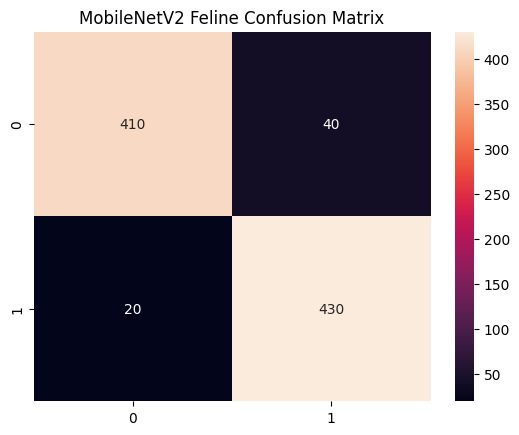

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


[EfficientNetB0] Epoch 1 | 2-Way 10-Shot | Loss=0.709 | Acc=52.56 | Time=28.13s
[EfficientNetB0] Epoch 2 | 2-Way 10-Shot | Loss=0.704 | Acc=50.78 | Time=27.68s
[EfficientNetB0] Epoch 3 | 2-Way 10-Shot | Loss=0.699 | Acc=53.67 | Time=27.84s
[EfficientNetB0] Epoch 4 | 2-Way 10-Shot | Loss=0.685 | Acc=54.33 | Time=27.87s
[EfficientNetB0] Epoch 5 | 2-Way 10-Shot | Loss=0.651 | Acc=60.89 | Time=28.86s
[EfficientNetB0] Epoch 6 | 2-Way 10-Shot | Loss=0.593 | Acc=67.67 | Time=27.42s
[EfficientNetB0] Epoch 7 | 2-Way 10-Shot | Loss=0.512 | Acc=75.44 | Time=27.46s
[EfficientNetB0] Epoch 8 | 2-Way 10-Shot | Loss=0.444 | Acc=79.33 | Time=27.62s
[EfficientNetB0] Epoch 9 | 2-Way 10-Shot | Loss=0.347 | Acc=86.22 | Time=28.04s
[EfficientNetB0] Epoch 10 | 2-Way 10-Shot | Loss=0.396 | Acc=82.00 | Time=27.44s
[EfficientNetB0] Epoch 11 | 2-Way 10-Shot | Loss=0.316 | Acc=87.00 | Time=27.80s
[EfficientNetB0] Epoch 12 | 2-Way 10-Shot | Loss=0.260 | Acc=89.44 | Time=27.90s
[EfficientNetB0] Epoch 13 | 2-Way 10-

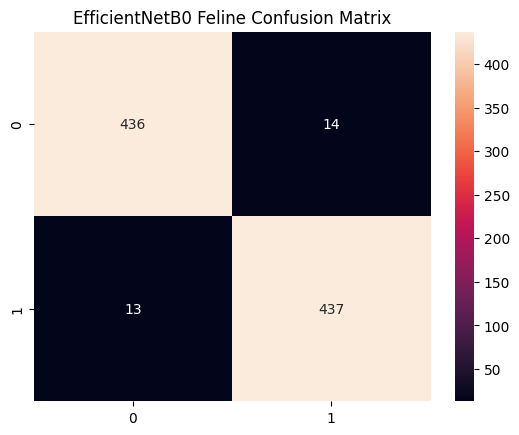


=== 3-Way Meta-Training (Human Student with KD, 5% training set) ===


Downloading: "https://download.pytorch.org/models/shufflenetv2_x0.5-f707e7126e.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x0.5-f707e7126e.pth
100%|██████████| 5.28M/5.28M [00:00<00:00, 59.0MB/s]


[Student KD] Epoch 1 | 3-Way 10-Shot | Loss=0.759 | Acc=42.30 | Time=49.21s
[Student KD] Epoch 2 | 3-Way 10-Shot | Loss=0.683 | Acc=43.19 | Time=49.50s
[Student KD] Epoch 3 | 3-Way 10-Shot | Loss=0.614 | Acc=57.26 | Time=49.15s
[Student KD] Epoch 4 | 3-Way 10-Shot | Loss=0.509 | Acc=72.74 | Time=49.31s
[Student KD] Epoch 5 | 3-Way 10-Shot | Loss=0.435 | Acc=82.22 | Time=49.73s
[Student KD] Epoch 6 | 3-Way 10-Shot | Loss=0.390 | Acc=88.67 | Time=49.49s
[Student KD] Epoch 7 | 3-Way 10-Shot | Loss=0.369 | Acc=95.11 | Time=50.39s
[Student KD] Epoch 8 | 3-Way 10-Shot | Loss=0.341 | Acc=97.56 | Time=49.90s
[Student KD] Epoch 9 | 3-Way 10-Shot | Loss=0.324 | Acc=98.52 | Time=49.62s
[Student KD] Epoch 10 | 3-Way 10-Shot | Loss=0.327 | Acc=99.04 | Time=49.26s
[Student KD] Epoch 11 | 3-Way 10-Shot | Loss=0.306 | Acc=99.41 | Time=49.14s
[Student KD] Epoch 12 | 3-Way 10-Shot | Loss=0.311 | Acc=99.70 | Time=49.17s
[Student KD] Epoch 13 | 3-Way 10-Shot | Loss=0.302 | Acc=99.48 | Time=49.75s
[Student

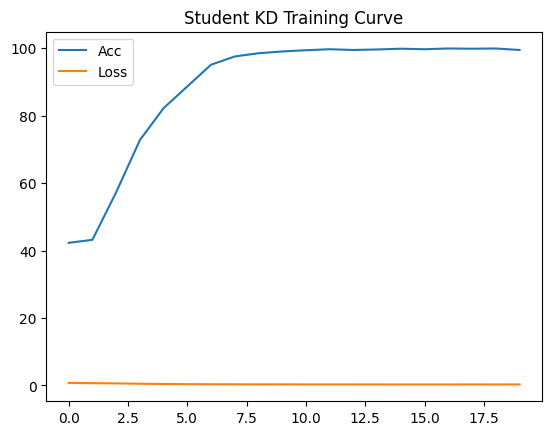

[Final Student KD] 3-Way 10-Shot | Acc=82.27, F1=82.06


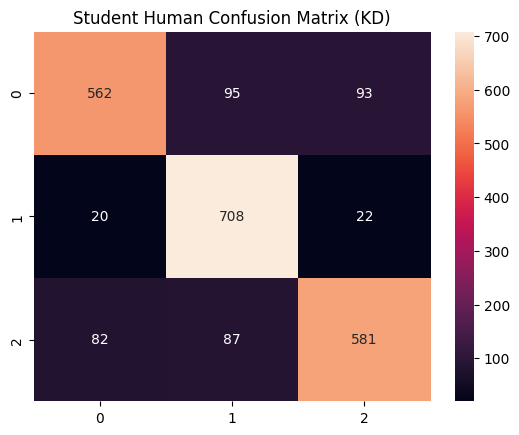

In [8]:
#!/usr/bin/env python3
# === Full FSL + KD Experiments with CSV Logging (GPU-only, pooling fixed, embedding KD improved) ===

import os, random, time, csv
from pathlib import Path
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU not available (forced GPU-only mode)")
DEVICE = torch.device("cuda:0")

FELINE_IMG_PATH = "/kaggle/input/cat-reticulocyte/felineAlldata"
HUMAN_IMG_PATH  = "/kaggle/input/human-reticulocyte/SubsetAlldata"

META_EPOCHS, EPISODES_PER_EPOCH = 20, 30
LR = 1e-4
SAVE_ROOT = Path("outputs_fsl_eval"); SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# ====================== DATA ======================
mean_imnet, std_imnet = [0.485,0.456,0.406], [0.229,0.224,0.225]
train_tf = transforms.Compose([
    transforms.Resize((224,224)),  
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(), transforms.Normalize(mean_imnet,std_imnet)
])
eval_tf = transforms.Compose([
    transforms.Resize((224,224)),  
    transforms.ToTensor(), transforms.Normalize(mean_imnet,std_imnet)
])

feline_base = datasets.ImageFolder(FELINE_IMG_PATH, transform=train_tf)

# --- Human dataset split: 5% train, 95% test ---
human_full = datasets.ImageFolder(HUMAN_IMG_PATH, transform=eval_tf)
train_len = max(1, int(0.05 * len(human_full)))
test_len = len(human_full) - train_len
human_train, human_test = random_split(human_full, [train_len, test_len],
                                       generator=torch.Generator().manual_seed(SEED))

# ====================== EPISODE SAMPLER ======================
class EpisodeSampler:
    def __init__(self, dataset, n_way, k_shot, q_query):
        self.dataset = dataset
        self.k_shot, self.q_query = k_shot, q_query
        self.cls_to_idx = {}
        for idx, (_, y) in enumerate(dataset):
            self.cls_to_idx.setdefault(y, []).append(idx)
        self.n_classes = len(self.cls_to_idx)
        self.n_way = min(n_way, self.n_classes)

    def sample_episode(self):
        chosen = random.sample(list(self.cls_to_idx.keys()), self.n_way)
        support_idx, query_idx = [], []
        for c in chosen:
            if len(self.cls_to_idx[c]) < self.k_shot + self.q_query:
                idxs = np.random.choice(self.cls_to_idx[c], self.k_shot + self.q_query, replace=True)
            else:
                idxs = random.sample(self.cls_to_idx[c], self.k_shot + self.q_query)
            support_idx += list(idxs[:self.k_shot])
            query_idx   += list(idxs[self.k_shot:])
        return Subset(self.dataset, support_idx), Subset(self.dataset, query_idx)

def make_loader(ds, batch=16, shuffle=False):
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=2, pin_memory=True)

# ====================== PROTOTYPICAL NETWORK ======================
class ProtoNet(nn.Module):
    def __init__(self, base_fn, embed_dim=128):
        super().__init__()
        base = base_fn(weights="DEFAULT")

        if hasattr(base, "fc"):   # ResNet-like
            in_f = base.fc.in_features
            base.fc = nn.Identity()
        elif hasattr(base, "classifier") and isinstance(base.classifier, nn.Sequential):
            if hasattr(base.classifier[-1], "in_features"):
                in_f = base.classifier[-1].in_features
            else:
                in_f = 512  
            base.classifier = nn.Identity()
        else:
            raise ValueError("Unknown base architecture")

        self.encoder = base
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  
        self.proj = nn.Linear(in_f, embed_dim)

    def forward(self, x):
        feat = self.encoder(x)          
        if feat.dim() == 4:
            feat = self.pool(feat)      
        feat = torch.flatten(feat, 1)   
        return self.proj(feat)

# ====================== STANDARD PROTO EPISODE ======================
def proto_episode(model,sup_loader,qry_loader,device):
    model.train()
    s_emb,s_lab=[],[]
    for x,y in sup_loader:
        s_emb.append(model(x.to(device))); s_lab.append(y.to(device))
    s_emb,s_lab=torch.cat(s_emb),torch.cat(s_lab)
    protos={int(c.item()):s_emb[s_lab==c].mean(0) for c in torch.unique(s_lab)}

    q_emb,q_lab=[],[]
    for x,y in qry_loader:
        q_emb.append(model(x.to(device))); q_lab.append(y.to(device))
    q_emb,q_lab=torch.cat(q_emb),torch.cat(q_lab)

    cls_list=list(protos.keys())
    proto_mat=torch.stack([protos[c] for c in cls_list])
    q_exp=q_emb.unsqueeze(1); p_exp=proto_mat.unsqueeze(0)
    dists=((q_exp - p_exp)**2).sum(-1)
    logits=-dists

    y_map={c:i for i,c in enumerate(cls_list)}
    targets=torch.tensor([y_map[int(y.item())] for y in q_lab],device=device)

    loss=F.cross_entropy(logits,targets)
    preds=logits.argmax(1)
    return loss, preds, targets

# ====================== KD LOSS ======================
def kd_loss(student_logits, teacher_logits, T=4.0):
    p_s = F.log_softmax(student_logits / T, dim=1)
    p_t = F.softmax(teacher_logits / T, dim=1)
    return F.kl_div(p_s, p_t, reduction="batchmean") * (T * T)

# ====================== PROTO EPISODE WITH KD ======================
def proto_episode_kd(student, teachers, sup_loader, qry_loader, device,
                    alpha=0.5, beta=0.4, gamma=0.1, T=4.0):
    student.train()
    # --- Student support embeddings ---
    s_emb, s_lab = [], []
    for x, y in sup_loader:
        s_emb.append(student(x.to(device))); s_lab.append(y.to(device))
    s_emb, s_lab = torch.cat(s_emb), torch.cat(s_lab)
    protos = {int(c.item()): s_emb[s_lab==c].mean(0) for c in torch.unique(s_lab)}

    # --- Student query embeddings ---
    q_emb, q_lab = [], []
    for x, y in qry_loader:
        q_emb.append(student(x.to(device))); q_lab.append(y.to(device))
    q_emb, q_lab = torch.cat(q_emb), torch.cat(q_lab)

    cls_list = list(protos.keys())
    proto_mat = torch.stack([protos[c] for c in cls_list])
    dists = ((q_emb.unsqueeze(1) - proto_mat.unsqueeze(0)) ** 2).sum(-1)
    logits_student = -dists

    # --- Targets ---
    y_map = {c:i for i,c in enumerate(cls_list)}
    targets = torch.tensor([y_map[int(y.item())] for y in q_lab], device=device)

    ce_loss = F.cross_entropy(logits_student, targets)

    # --- Teacher guidance ---
    kd_losses, feat_losses = [], []
    for teacher in teachers:
        teacher.eval()
        with torch.no_grad():
            # Teacher support embeddings
            s_emb_t, s_lab_t = [], []
            for x, y in sup_loader:
                s_emb_t.append(teacher(x.to(device))); s_lab_t.append(y.to(device))
            s_emb_t, s_lab_t = torch.cat(s_emb_t), torch.cat(s_lab_t)

            # Teacher query embeddings
            q_emb_t, q_lab_t = [], []
            for x, y in qry_loader:
                q_emb_t.append(teacher(x.to(device))); q_lab_t.append(y.to(device))
            q_emb_t, q_lab_t = torch.cat(q_emb_t), torch.cat(q_lab_t)

        proto_t = {int(c.item()): s_emb_t[s_lab_t==c].mean(0) for c in torch.unique(s_lab_t)}
        proto_mat_t = torch.stack([proto_t[c] for c in cls_list])
        dists_t = ((q_emb_t.unsqueeze(1) - proto_mat_t.unsqueeze(0)) ** 2).sum(-1)
        logits_teacher = -dists_t

        kd_losses.append(kd_loss(logits_student, logits_teacher, T=T))

        # embedding alignment: support + query
        feat_losses.append(F.mse_loss(torch.cat([s_emb, q_emb]), torch.cat([s_emb_t, q_emb_t])))

    kd_term = sum(kd_losses) / len(kd_losses)
    feat_term = sum(feat_losses) / len(feat_losses)

    total_loss = alpha * ce_loss + beta * kd_term + gamma * feat_term
    preds = logits_student.argmax(1)
    return total_loss, preds, targets

# ====================== META-TRAIN FUNCTION ======================
def meta_train(model_name, base_fn, dataset, n_way, k_shot, q_query,
               meta_epochs, episodes_per_epoch, device, save_csv=None):
    model=ProtoNet(base_fn).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    history={"loss":[],"acc":[]}
    for ep in range(1,meta_epochs+1):
        start=time.time()
        accs,losses=[],[]
        sampler=EpisodeSampler(dataset,n_way,k_shot,q_query)
        for _ in range(episodes_per_epoch):
            sup,qry=sampler.sample_episode()
            sup_loader,qry_loader=make_loader(sup,8,True),make_loader(qry,8,False)
            loss,preds,targets=proto_episode(model,sup_loader,qry_loader,device)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
            accs.append((preds==targets).float().mean().item()*100)
        end=time.time()
        mean_loss,mean_acc=np.mean(losses),np.mean(accs)
        history["loss"].append(mean_loss); history["acc"].append(mean_acc)
        print(f"[{model_name}] Epoch {ep} | {n_way}-Way {k_shot}-Shot "
              f"| Loss={mean_loss:.3f} | Acc={mean_acc:.2f} | Time={end-start:.2f}s")
        if save_csv:
            with open(save_csv,"a",newline="") as f:
                writer=csv.writer(f)
                writer.writerow([f"{model_name}_{n_way}way_{k_shot}shot_E{ep}",
                                 mean_loss,mean_acc,end-start])
    return model, history

# ====================== META-TRAIN STUDENT WITH KD ======================
def meta_train_student_kd(student, teachers, dataset, n_way, k_shot, q_query,
                          meta_epochs, episodes_per_epoch, device,
                          alpha=0.5, beta=0.4, gamma=0.1, T=4.0, save_csv=None):
    opt=torch.optim.Adam(student.parameters(),lr=LR)
    history={"loss":[],"acc":[]}
    for ep in range(1,meta_epochs+1):
        start=time.time()
        accs,losses=[],[]
        sampler=EpisodeSampler(dataset,n_way,k_shot,q_query)
        for _ in range(episodes_per_epoch):
            sup,qry=sampler.sample_episode()
            sup_loader,qry_loader=make_loader(sup,8,True),make_loader(qry,8,False)
            loss,preds,targets=proto_episode_kd(student,teachers,sup_loader,qry_loader,
                                                device,alpha,beta,gamma,T)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
            accs.append((preds==targets).float().mean().item()*100)
        end=time.time()
        mean_loss,mean_acc=np.mean(losses),np.mean(accs)
        history["loss"].append(mean_loss); history["acc"].append(mean_acc)
        print(f"[Student KD] Epoch {ep} | {n_way}-Way {k_shot}-Shot "
              f"| Loss={mean_loss:.3f} | Acc={mean_acc:.2f} | Time={end-start:.2f}s")
        if save_csv:
            with open(save_csv,"a",newline="") as f:
                writer=csv.writer(f)
                writer.writerow([f"StudentKD_{n_way}way_{k_shot}shot_E{ep}",
                                 mean_loss,mean_acc,end-start])
    return student, history

# ====================== EVALUATION ======================
@torch.no_grad()
def evaluate(model,dataset,n_way,k_shot,q_query,episodes=30,save_csv=None,exp_name="exp"):
    sampler=EpisodeSampler(dataset,n_way,k_shot,q_query)
    all_preds,all_true=[],[]
    for _ in range(episodes):
        sup,qry=sampler.sample_episode()
        sup_loader,qry_loader=make_loader(sup,8),make_loader(qry,8)
        _,preds,targets=proto_episode(model,sup_loader,qry_loader,DEVICE)
        all_preds.extend(preds.cpu().numpy()); all_true.extend(targets.cpu().numpy())
    acc=accuracy_score(all_true,all_preds)*100
    f1=f1_score(all_true,all_preds,average="macro")*100
    prec=precision_score(all_true,all_preds,average=None,zero_division=0)
    rec=recall_score(all_true,all_preds,average=None,zero_division=0)
    cm=confusion_matrix(all_true,all_preds)
    print(f"[{exp_name}] {n_way}-Way {k_shot}-Shot | Acc={acc:.2f}, F1={f1:.2f}")
    if save_csv:
        with open(save_csv,"a",newline="") as f:
            writer=csv.writer(f)
            row=[f"{exp_name}_{n_way}way_{k_shot}shot",acc,f1]+list(prec)+list(rec)
            writer.writerow(row)
    return acc,f1,prec,rec,cm

# ====================== MAIN ======================
if __name__=="__main__":
    teacher_csv=SAVE_ROOT/"teachers_results.csv"
    student_csv=SAVE_ROOT/"student_results.csv"
    with open(teacher_csv,"w",newline="") as f:
        writer=csv.writer(f); writer.writerow(["Exp","Loss","Acc","Time"])
    with open(student_csv,"w",newline="") as f:
        writer=csv.writer(f); writer.writerow(
            ["Exp","Acc","F1","Prec_class1","Prec_class2","Prec_class3",
             "Rec_class1","Rec_class2","Rec_class3"])

    # === 1. Train Teachers on Feline ===
    print("\n=== 2-Way Meta-Training (Feline Teachers) ===")
    teachers=[]
    for name,fn in [("MobileNetV2", models.mobilenet_v2),
                    ("EfficientNetB0", models.efficientnet_b0)]:
        model,hist=meta_train(name,fn,feline_base,2,10,15,
                              META_EPOCHS,EPISODES_PER_EPOCH,DEVICE,save_csv=teacher_csv)
        teachers.append(model.eval().requires_grad_(False))
        acc,f1,prec,rec,cm=evaluate(model,feline_base,2,10,15,
                                    episodes=30,save_csv=teacher_csv,exp_name=name)
        sns.heatmap(cm,annot=True,fmt="d"); plt.title(f"{name} Feline Confusion Matrix"); plt.show()

    # === 2. Train Student with KD on Human (5% train) ===
    print("\n=== 3-Way Meta-Training (Human Student with KD, 5% training set) ===")
    student=ProtoNet(models.shufflenet_v2_x0_5).to(DEVICE)
    student,hist=meta_train_student_kd(student,teachers,human_train,
                                       3,10,15,META_EPOCHS,EPISODES_PER_EPOCH,
                                       DEVICE,alpha=0.5,beta=0.4,gamma=0.1,T=4.0,save_csv=student_csv)

    for k in range(1,11):
        acc,f1,prec,rec,cm=evaluate(student,human_test,3,k,15,
                                    episodes=30,save_csv=student_csv,
                                    exp_name=f"StudentKD_{k}shot")
        print(f"[Student KD] {k}-Shot done")

    # curves
    plt.figure(); plt.plot(hist["acc"],label="Acc"); plt.plot(hist["loss"],label="Loss")
    plt.legend(); plt.title("Student KD Training Curve"); plt.show()

    # final eval + confusion matrix
    acc,f1,prec,rec,cm=evaluate(student,human_test,3,10,15,episodes=50,
                                exp_name="Final Student KD",save_csv=student_csv)
    sns.heatmap(cm,annot=True,fmt="d"); plt.title("Student Human Confusion Matrix (KD)"); plt.show()
